In [122]:
import scipy as sp
#from scipy.misc import derivative
from scipy.special import jv, hankel2, hankel1, yv, jvp, yvp, factorial
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, pi, exp, conj, argmin, unravel_index, log, einsum, tan, log10, acosh, tanh, acos, cos, sin
import torch
import warnings
warnings.filterwarnings("ignore")
from utils import h_z_cpa, h_z_cpa_numerator, e_z_cpa, e_z_cpa_numerator, hl2_prime, hl1_prime, hbar, c, alpha, graphene_conductivity
tau = 6.4*1e-13 # scattering time in seconds

In [119]:
def j_nu_approximation(x, m):
    alpha = acosh(m/x)
    beta = acos(m/x)
    approx_array_x_lt_m = exp(m*tanh(alpha)-m*alpha)/sqrt(2*pi*m*tanh(alpha))
    approx_array_x_gt_m = sqrt(2/(m*pi*tan(beta)))*cos(m*tan(beta)-m*beta-pi/4)
    approx_array = np.where(x<m, approx_array_x_lt_m, approx_array_x_gt_m)
    return approx_array


def y_nu_approximation(x, m):
    alpha = acosh(m/x)
    beta = acos(m/x)
    approx_array_x_lt_m = -2*exp(-m*tanh(alpha)+m*alpha)/sqrt(2*pi*m*tanh(alpha))
    approx_array_x_gt_m = sqrt(2/(m*pi*tan(beta)))*sin(m*tan(beta)-m*beta-pi/4)
    approx_array = np.where(x<m, approx_array_x_lt_m, approx_array_x_gt_m)
    return approx_array

In [136]:
m = 190
M = 1000
x = linspace(150, 300, M)

In [137]:
jv_exact = jv(m, x)
jv_approx = j_nu_approximation(x, m)

yv_exact = yv(m, x)
yv_approx = y_nu_approximation(x, m)

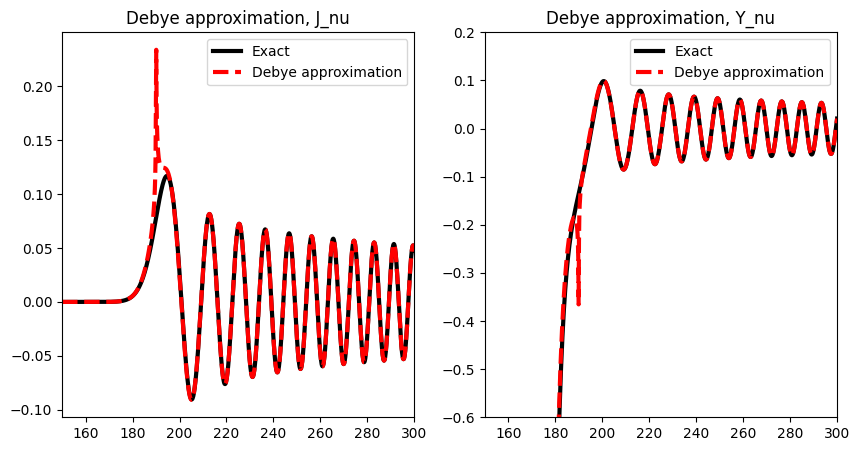

In [147]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.plot(x, jv_exact, color="black", linewidth=3, label="Exact")
ax1.plot(x, jv_approx, color="red", linestyle="dashed", linewidth=3, label="Debye approximation")
ax1.set_xlim(x.min(), x.max());

ax2.plot(x, yv_exact, color="black", linewidth=3, label="Exact")
ax2.plot(x, yv_approx, color="red", linestyle="dashed", linewidth=3, label="Debye approximation")
ax2.set_xlim(x.min(), x.max());
ax2.set_ylim(-0.6, 0.2);

ax1.legend()
ax2.legend()
ax1.set_title("Debye approximation, J_nu")
ax2.set_title("Debye approximation, Y_nu");